In [3]:
import numpy as no
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

In [5]:
prices =  pd.read_csv(
    "./data/etf_prices_daily.csv",
    index_col = 0,
    parse_dates=True
)

print("Dataset shape:", prices.shape)
print("Data range:", prices.index.min().date(), "to", prices.index.max().date())

prices.head()

Dataset shape: (2911, 6)
Data range: 2015-01-02 to 2026-07-31


,GLD,IWM,QQQ,SPY,TLT,VNQ
Date,,,,,,
2015-01-02,114.080002,102.543129,94.561104,169.687866,92.287552,52.090744
2015-01-05,115.800003,101.172203,93.174072,166.623322,93.737244,52.375847
2015-01-06,117.120003,99.421906,91.924744,165.053925,95.426125,52.895351
2015-01-07,116.430000,100.646286,93.109749,167.110672,95.237640,53.706303
2015-01-08,115.940002,102.353447,94.891846,170.076050,93.976433,53.909031


In [8]:
monthly_prices = prices.resample("ME").last()

print("Monthly price table shape:", monthly_prices.shape)
monthly_prices.head()

Monthly price table shape: (139, 6)


,GLD,IWM,QQQ,SPY,TLT,VNQ
Date,,,,,,
2015-01-31,123.449997,99.758163,92.870934,164.748337,100.231834,54.834019
2015-02-28,116.160004,105.690216,99.576714,174.007935,94.079224,52.819321
2015-03-31,113.660004,107.560898,97.227737,171.275024,95.106819,53.734112
2015-04-30,113.470001,104.802040,99.096794,172.959290,91.849228,50.592041
2015-05-31,114.099998,107.145790,101.324928,175.182861,89.670158,50.439068


In [10]:
monthly_returns = monthly_prices.pct_change()
monthly_returns.head(15)

,GLD,IWM,QQQ,SPY,TLT,VNQ
Date,,,,,,
2015-01-31,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-28,-0.059052,0.059464,0.072205,0.056204,-0.061384,-0.036742
2015-03-31,-0.021522,0.017700,-0.023590,-0.015706,0.010923,0.017319
2015-04-30,-0.001672,-0.025649,0.019223,0.009834,-0.034252,-0.058474
2015-05-31,0.005552,0.022364,0.022484,0.012856,-0.023724,-0.003024
2015-06-30,-0.015162,0.007829,-0.024841,-0.020312,-0.040720,-0.046687
2015-07-31,-0.066210,-0.011039,0.045578,0.022589,0.045460,0.057705
2015-08-31,0.037072,-0.063110,-0.068245,-0.060950,-0.006895,-0.062912
2015-09-30,-0.018011,-0.049363,-0.022073,-0.025516,0.019669,0.030597


In [11]:
momentum_12_1 =(
    monthly_prices.shift(1) / monthly_prices.shift(12)
)-1

momentum_12_1.tail()

,GLD,IWM,QQQ,SPY,TLT,VNQ
Date,,,,,,
2026-03-31,0.678871,0.322161,0.299712,0.236998,0.039092,0.087289
2026-04-30,0.416499,0.286424,0.219791,0.186200,0.008863,0.044124
2026-05-31,0.395455,0.370096,0.292543,0.233306,0.033577,0.121372
2026-06-30,0.368369,0.356645,0.343361,0.234760,0.012126,0.106420
2026-07-31,0.215936,0.383703,0.309617,0.194539,0.035731,0.123677


In [15]:
latest_date= momentum_12_1.dropna().index[-1]

latest_ranking =(
    momentum_12_1.loc[latest_date]
    .sort_values(ascending=False)
    .to_frame(name="12-1 Momentum")
)

latest_ranking["12-1 Momentum (%)"]=(
    latest_ranking["12-1 Momentum"]*100
)
latest_ranking[["12-1 Momentum (%)"]].round(2)

,12-1 Momentum (%)
IWM,38.37
QQQ,30.96
GLD,21.59
SPY,19.45
VNQ,12.37
TLT,3.57


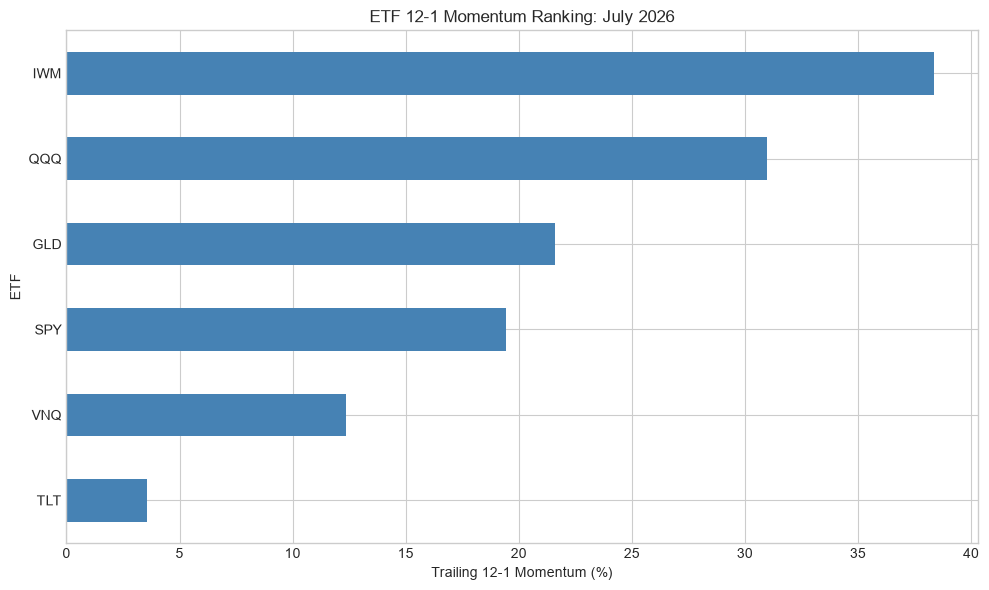

In [18]:
latest_ranking["12-1 Momentum (%)"].sort_values().plot(
    kind="barh",
    figsize=(10,6),
    color="steelblue"
)

plt.title(f"ETF 12-1 Momentum Ranking: {latest_date:%B %Y}")
plt.xlabel("Trailing 12-1 Momentum (%)")
plt.ylabel("ETF")
plt.tight_layout()
plt.show()